In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import sklearn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from google.colab import drive; drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
mushrooms_DataFrame = pd.read_csv('/content/drive/MyDrive/ML/Lab_2/mushrooms.csv')
print(mushrooms_DataFrame.info)


<bound method DataFrame.info of      class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0        p         x           s         n       t    p               f   
1        e         x           s         y       t    a               f   
2        e         b           s         w       t    l               f   
3        p         x           y         w       t    p               f   
4        e         x           s         g       f    n               f   
...    ...       ...         ...       ...     ...  ...             ...   
8119     e         k           s         n       f    n               a   
8120     e         x           s         n       f    n               a   
8121     e         f           s         n       f    n               a   
8122     p         k           y         n       f    y               f   
8123     e         x           s         n       f    n               a   

     gill-spacing gill-size gill-color  ... stalk-surface-below-rin

In [11]:
# Словарь с русскими названиями и расшифровкой значений
feature_info = {
    'cap-shape': {
        'ru': 'Форма шляпки',
        'values': {'b': 'колокольчатая', 'c': 'коническая', 'x': 'выпуклая', 'f': 'плоская', 'k': 'выпукло-вогнутая', 's': 'с углублением'}
    },
    'cap-surface': {
        'ru': 'Поверхность шляпки',
        'values': {'f': 'волокнистая', 'g': 'гладкая', 's': 'чешуйчатая', 'y': 'чешуйчато-волокнистая'}
    },
    'cap-color': {
        'ru': 'Цвет шляпки',
        'values': {'n': 'коричневый', 'b': 'желтовато-коричневый', 'c': 'коричневато-красный', 'g': 'серый', 'r': 'зеленоватый', 'p': 'розовый', 'u': 'фиолетовый', 'e': 'красный', 'w': 'белый', 'y': 'желтый'}
    },
    'bruises': {
        'ru': 'Синяки/повреждения',
        'values': {'t': 'есть', 'f': 'нет'}
    },
    'odor': {
        'ru': 'Запах',
        'values': {'a': 'миндальный', 'l': 'анисовый', 'c': 'креозотовый', 'y': 'рыбный', 'f': 'неприятный', 'm': 'затхлый', 'n': 'нет', 'p': 'пряный', 's': 'едкий'}
    },
    'gill-attachment': {
        'ru': 'Крепление пластинок',
        'values': {'a': 'приросшие', 'd': 'свободные', 'f': 'зазубренные', 'n': 'вдавленные'}
    },
    'gill-spacing': {
        'ru': 'Расстояние между пластинками',
        'values': {'c': 'частые', 'w': 'редкие', 'd': 'сросшиеся'}
    },
    'gill-size': {
        'ru': 'Размер пластинок',
        'values': {'b': 'широкие', 'n': 'узкие'}
    },
    'gill-color': {
        'ru': 'Цвет пластинок',
        'values': {'k': 'черный', 'n': 'коричневый', 'b': 'желтовато-коричневый', 'h': 'шоколадный', 'g': 'серый', 'r': 'зеленоватый', 'o': 'оранжевый', 'p': 'розовый', 'u': 'фиолетовый', 'e': 'красный', 'w': 'белый', 'y': 'желтый'}
    },
    'stalk-shape': {
        'ru': 'Форма ножки',
        'values': {'e': 'расширяющаяся кверху', 't': 'сужающаяся кверху'}
    },
    'stalk-root': {
        'ru': 'Корень ножки',
        'values': {'b': 'луковичный', 'c': 'клубневидный', 'u': 'чашевидный', 'e': 'равномерный', 'z': 'веретенообразный', 'r': 'корневидный', '?': 'неизвестно'}
    },
    'stalk-surface-above-ring': {
        'ru': 'Поверхность ножки выше кольца',
        'values': {'f': 'волокнистая', 'y': 'чешуйчатая', 'k': 'шелковистая', 's': 'гладкая'}
    },
    'stalk-surface-below-ring': {
        'ru': 'Поверхность ножки ниже кольца',
        'values': {'f': 'волокнистая', 'y': 'чешуйчатая', 'k': 'шелковистая', 's': 'гладкая'}
    },
    'stalk-color-above-ring': {
        'ru': 'Цвет ножки выше кольца',
        'values': {'n': 'коричневый', 'b': 'желтовато-коричневый', 'c': 'коричневато-красный', 'g': 'серый', 'r': 'зеленоватый', 'p': 'розовый', 'u': 'фиолетовый', 'e': 'красный', 'w': 'белый', 'y': 'желтый'}
    },
    'stalk-color-below-ring': {
        'ru': 'Цвет ножки ниже кольца',
        'values': {'n': 'коричневый', 'b': 'желтовато-коричневый', 'c': 'коричневато-красный', 'g': 'серый', 'r': 'зеленоватый', 'p': 'розовый', 'u': 'фиолетовый', 'e': 'красный', 'w': 'белый', 'y': 'желтый'}
    },
    'veil-type': {
        'ru': 'Тип вуали',
        'values': {'p': 'пленчатая', 'u': 'отсутствует'}
    },
    'veil-color': {
        'ru': 'Цвет вуали',
        'values': {'n': 'коричневый', 'o': 'оранжевый', 'w': 'белый', 'y': 'желтый'}
    },
    'ring-number': {
        'ru': 'Количество колец',
        'values': {'n': 'нет', 'o': 'одно', 't': 'два'}
    },
    'ring-type': {
        'ru': 'Тип кольца',
        'values': {'c': 'кобвевидное', 'e': 'свисающее', 'f': 'веерообразное', 'l': 'крупное', 'n': 'отсутствует', 'p': 'перистое', 's': 'зонтиковидное', 'z': 'утолщенное'}
    },
    'spore-print-color': {
        'ru': 'Цвет спорового отпечатка',
        'values': {'k': 'черный', 'n': 'коричневый', 'b': 'желтовато-коричневый', 'h': 'шоколадный', 'r': 'зеленоватый', 'o': 'оранжевый', 'u': 'фиолетовый', 'w': 'белый', 'y': 'желтый'}
    },
    'population': {
        'ru': 'Популяция',
        'values': {'a': 'обильная', 'c': 'кластерная', 'n': 'рассеянная', 's': 'разреженная', 'v': 'многочисленная', 'y': 'отдельные экземпляры'}
    },
    'habitat': {
        'ru': 'Среда обитания',
        'values': {'g': 'луга', 'l': 'лиственные леса', 'm': 'луга и поля', 'p': 'парки', 'u': 'урбанизированные зоны', 'w': 'лесные массивы', 'd': 'хвойные леса'}
    }
}

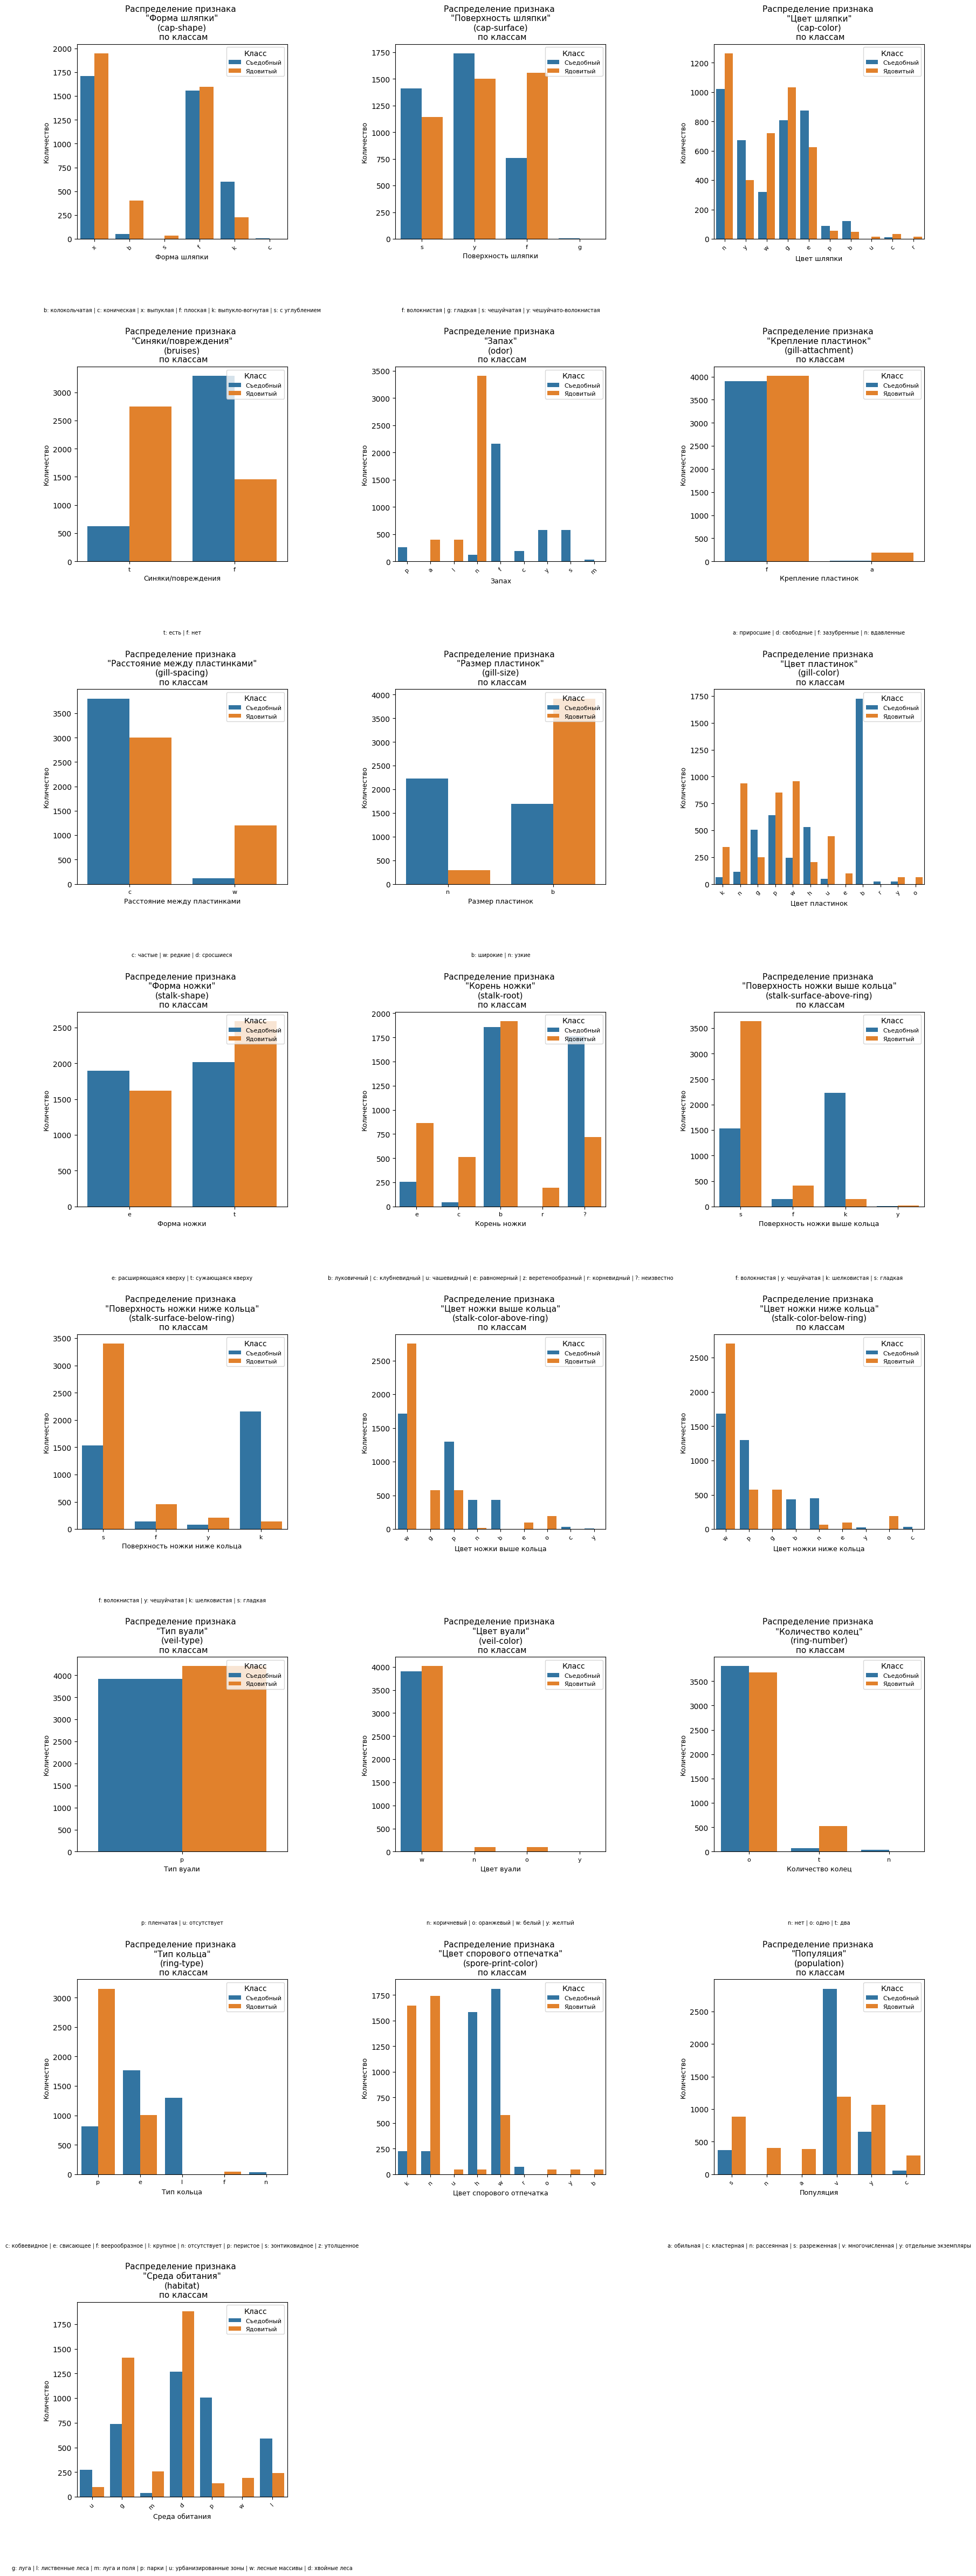

In [19]:
categorical_features = mushrooms_DataFrame.columns[1:]

n_features = len(categorical_features)
n_cols = 3  # кол-во колонок
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))  # шире и выше
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    ru_name = feature_info.get(feature, {}).get('ru', feature)

    sns.countplot(data=mushrooms_DataFrame, x=feature, hue='class', ax=axes[i])
    axes[i].set_title(f'Распределение признака \n"{ru_name}"\n({feature})\n по классам', fontsize=11)
    axes[i].set_xlabel(ru_name, fontsize=9)
    axes[i].set_ylabel('Количество', fontsize=9)
    axes[i].legend(title='Класс', labels=['Съедобный', 'Ядовитый'], loc='upper right', fontsize=8)

    # Поворот подписей, если их много
    if len(mushrooms_DataFrame[feature].unique()) > 5:
        axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    else:
        axes[i].tick_params(axis='x', labelsize=8)

    if feature in feature_info and 'values' in feature_info[feature]:
        value_map = feature_info[feature]['values']
        if len(value_map) <= 8:
            legend_text = ' | '.join([f'{k}: {v}' for k, v in value_map.items()])
            axes[i].text(0.5, -0.35, legend_text, transform=axes[i].transAxes,
                        fontsize=7, ha='center', va='top', wrap=True)

# Удаление пустых субплотов (если есть)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [20]:
def compute_decision_functions(mushrooms_DataFrame, feature):
    cross_tab = pd.crosstab(index=mushrooms_DataFrame[feature], columns=mushrooms_DataFrame['class'], margins=True, margins_name="Total")
    class_frequencies = cross_tab.div(cross_tab['Total'], axis=0)
    return class_frequencies


def predict_class(decision_function, value):
    return 'e' if decision_function.loc[value]['e'] > decision_function.loc[value]['p'] else 'p'

accuracies = []
for feature in categorical_features:
    decision_function = compute_decision_functions(mushrooms_DataFrame, feature)
    predictions = mushrooms_DataFrame[feature].apply(lambda x: predict_class(decision_function, x))
    accuracy = metrics.accuracy_score(mushrooms_DataFrame['class'], predictions)
    accuracies.append(accuracy)
    print(f"Точность предсказания для признака '{feature}': {accuracy}")


max_accuracy = max(accuracies)
print(f"MAX = {max_accuracy}")


Точность предсказания для признака 'cap-shape': 0.5642540620384048
Точность предсказания для признака 'cap-surface': 0.5805022156573116
Точность предсказания для признака 'cap-color': 0.5952732644017725
Точность предсказания для признака 'bruises': 0.7439684884293452
Точность предсказания для признака 'odor': 0.9852289512555391
Точность предсказания для признака 'gill-attachment': 0.517971442639094
Точность предсказания для признака 'gill-spacing': 0.6159527326440177
Точность предсказания для признака 'gill-size': 0.7562776957163959
Точность предсказания для признака 'gill-color': 0.8050221565731167
Точность предсказания для признака 'stalk-shape': 0.5529295913343181
Точность предсказания для признака 'stalk-root': 0.6459871984244214
Точность предсказания для признака 'stalk-surface-above-ring': 0.7744953225012309
Точность предсказания для признака 'stalk-surface-below-ring': 0.7661250615460364
Точность предсказания для признака 'stalk-color-above-ring': 0.7163958641063516
Точность пре

In [21]:
y = mushrooms_DataFrame['class']
X = mushrooms_DataFrame.copy().drop(['class'], axis=1)

for feature in mushrooms_DataFrame.columns[1:]:
    X[feature] = mushrooms_DataFrame[feature].apply(lambda x : ord(x))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

nb_classifier = CategoricalNB()
nb_classifier.fit(X, y)

predictions = nb_classifier.predict(X_test)

accuracy = metrics.accuracy_score(y_test, predictions)
print(f"Точность наивного байесовского классификатора: {accuracy}")


Точность наивного байесовского классификатора: 0.9532307692307692


In [22]:
import numpy as np

class CategoricalNaiveBayes:
    def __init__(self):
        self.cross_dict = {}

    def fit(self, X, y):
        self._X = X
        self._y = y
        for feature in X.columns:
            crosstable = pd.crosstab(X[feature], y, margins=True, margins_name='total')
            #print(crosstable['e'][102])
            self.cross_dict[feature] = crosstable

    def predict(self, X, alpha):
        predictions = []
        for row_id, *feature_values in X.itertuples():
            result_e = 1
            result_p = 1
            for feature_id, feature_name in enumerate(self._X.columns):
                crosstable = self.cross_dict.get(feature_name)
                feature_value = feature_values.pop(0)
                result_e *= (crosstable['e'][feature_value] + alpha)/(crosstable['e']['total'] + alpha * (len(crosstable)-1))
                result_p *= (crosstable['p'][feature_value]+ alpha)/(crosstable['p']['total'] + alpha * (len(crosstable)-1))

            result_e *= (crosstable['e']['total'] + alpha)/(crosstable['total']['total'] + alpha * (len(crosstable)-1))
            result_p *= (crosstable['p']['total'] + alpha)/(crosstable['total']['total'] + alpha * (len(crosstable)-1))

            result = result_e - result_p
            predictions.append('e' if result >=0 else 'p')

        return predictions


In [23]:
y = mushrooms_DataFrame['class']
X = mushrooms_DataFrame.copy().drop(['class'], axis=1)

for feature in mushrooms_DataFrame.columns[1:]:
    X[feature] = mushrooms_DataFrame[feature].apply(lambda x : ord(x))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


nb_classifier = CategoricalNaiveBayes()
nb_classifier.fit(X_train, y_train)

predictions = nb_classifier.predict(X_test, 0)

accuracy = metrics.accuracy_score(y_test, predictions)
print(f"Точность наивного байесовского классификатора: {accuracy}")


Точность наивного байесовского классификатора: 0.9963076923076923


In [24]:
mushrooms_DataFrame = pd.get_dummies(mushrooms_DataFrame)

X = mushrooms_DataFrame.drop('class_e', axis=1)
y = mushrooms_DataFrame['class_e']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)
# Возвращает матрицу оценок вероятностей
probabilities = model.predict_proba(X_test)

# Берём второй столбец с вероятностями для съедобных
probabilities = probabilities[:, 1]

# Обратному логистическое преобразование
log_odds = np.log(probabilities / (1 - probabilities))

# Если значение >0, то True == съедобноые
predictions = (log_odds > 0).astype(bool)

# Сравнение
accuracy = metrics.accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)


Accuracy: 1.0
